In [1]:
!hostname

node062


In [11]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

## Get participant data for current pipeline

In [2]:
#### Load in experiment manifests with full transcripts
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

def get_part_meta_dict(meta_file_name):
    part_manifest = pd.read_pickle(meta_file_name)
    records = []
    trial_ix_count = 0 
    for block_name, block in part_manifest.items():
        if isinstance(block, dict):
            for trial_ix, trial_dict in block.items():
                trial_dict['trial_num'] = trial_ix_count
                trial_dict['target_azimuth'] = trial_dict['target_loc'][0] 
                trial_dict['target_elev'] = trial_dict['target_loc'][1]
                trial_dict['distractor_azimuth'] = trial_dict['distractor_loc'][0]
                trial_dict['distractor_elev'] = trial_dict['distractor_loc'][1]
                trial_dict['block_name'] = block_name
                records.append(trial_dict)
                trial_ix_count += 1

        elif isinstance(block, list):
            for trial in block:
                trial['target_azimuth'] = trial['target_loc'][0]
                trial['target_elev'] = trial['target_loc'][1]
                trial['distractor_azimuth'] = trial['distractor_loc'][0]
                trial['distractor_elev'] = trial['distractor_loc'][1]
                trial['block_name'] = block_name
                trial['cue_fn'] = Path(trial['cue_fn'][0]).stem
                trial['target_fn'] = Path(trial['target_fn'][0]).stem
                trial['distractor_fn'] = Path(trial['distractor_fn'][0]).stem
                records.append(trial)
    

    meta_df = pd.DataFrame(records)
    meta_df.drop(columns=['target_loc', 'distractor_loc'], inplace=True)
    if 'global_trial_ix' in meta_df.columns:
        meta_df.rename(columns={'global_trial_ix': 'trial_num'}, inplace=True)
    return meta_df

def get_part_manifest(manifest_file_name):
    part_manifest = pd.read_pickle(manifest_file_name)
    records = []
    for ix, trial_manifest in enumerate(part_manifest):
        trial_dict = {}
        trial_dict['trial_num'] = ix
        # trial_dict['target_azimuth'] = trial_manifest[0][0]
        # trial_dict['target_elev'] = trial_manifest[0][1]
        # trial_dict['distractor_azimuth'] = trial_manifest[1][0]
        # trial_dict['distractor_elev'] = trial_manifest[1][1]
        # trial_dict['snr'] = trial_manifest[2]
        trial_dict['cue_fn'] = Path(trial_manifest[3][0]).stem
        trial_dict['target_fn'] = Path(trial_manifest[4][0]).stem
        trial_dict['distractor_fn'] = Path(trial_manifest[5][0]).stem

        records.append(trial_dict)
    manifest_df = pd.DataFrame(records)
    return manifest_df

In [3]:


# Add elev delta trials 
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v00/'
exp_manifest_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v00/'
part_results = sorted(list(Path(result_path).glob('*.csv')))
meta_files = sorted(list(Path(exp_manifest_path).glob('*meta.pkl')))
manifest_files = sorted(list(Path(exp_manifest_path).glob('*manifest.pkl')))

result_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/spotlight_v01/'
exp_manifest_path_v1 = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/spotlight_v01/'
part_results += sorted(list(Path(result_path_v1).glob('*.csv')))
meta_files += sorted(list(Path(exp_manifest_path_v1).glob('*meta.pkl')))
manifest_files += sorted(list(Path(exp_manifest_path_v1).glob('*manifest.pkl')))
# results += results
# manifests += manifests

# meta_files
manifest_dict = {}
meta_dict = {}

for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    if 'v01' in meta_file.parent.stem:
        part_name += '_v01'
    meta_dict[part_name] = meta_file

for manifest_file in manifest_files:
    if 'pilot' in manifest_file.parent.stem:
        part_name = "pilot_" + "_".join(manifest_file.stem.split('_')[:2])

    else:
        part_name = "_".join(manifest_file.stem.split('_')[:2])
    if 'v01' in manifest_file.parent.stem:
        part_name += '_v01'
    manifest_dict[part_name] = manifest_file

block_name_map = {
    'target_0': "block_front",
    'target_40': "block_fourty",
    'target_90': "block_ninety",
}

dfs = []
for result_file in part_results:
    try:
        part_name = result_file.stem
        # print(part_name)
        # remove space 
        if '000' in part_name:
            continue
        if 'pilot' in result_file.parent.stem:
            part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
        if ' ' in part_name:
            part_name = part_name.split(' ')[0]
        if 'test' not in part_name: 
            part_ix = int(re.search(r'\d+', part_name).group())
            part_name_str = f"participant_{part_ix:03d}"
        if 'test' in part_name:
            continue
        if 'v01' in result_file.parent.stem:
            part_name_str += '_v01'

        meta_file = meta_dict[part_name_str]
        manifest_file = manifest_dict[part_name_str]
        part_df = util_process.get_part_df(result_file)
        meta_df = get_part_meta_dict(meta_file)
        manifest_df = get_part_manifest(manifest_file)
        # merge on shared trial_index
        part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
                meta_df, left_on='trial_num', right_on='trial_num',)
        if 'cue_fn' not in part_df.columns:
            part_df = pd.merge(part_df, manifest_df, left_on='trial_num', right_on='trial_num')
        part_df['participant'] = part_name_str
        if part_df.block_name.str.contains('target').any():
            part_df['block_name'] = [block_name_map['_'.join(block.split('_')[:2])] for block in part_df.block_name]
        dfs.append(part_df)
    except Exception as e:
        print(e)
        print(result_file)
        continue

results_df = pd.concat(dfs, ignore_index=True)
results_df['abs_target_azim'] = results_df.target_azimuth.abs()
results_df['dist_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.target_fn.to_list()]


cols_to_score = ['response', 'target_word', 'distractor_word', 'target_transcripts', 'dist_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_word, target_transcripts, dist_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_transcripts or response == distractor_word))

results_df['correct'] = correct
results_df['confusions'] = confusions

In [6]:
results_df['computed_azim_delta'] = np.abs(results_df['distractor_azimuth'] - results_df['target_azimuth'])

In [7]:
# group data 

results_summary = results_df.groupby(['participant', 'block_name', 'azim_delta']).agg({'correct': ['mean', 'count'], 'confusions':['mean']}).reset_index()
# flatten multiindex
results_summary.columns = ['_'.join(col).strip() for col in results_summary.columns.values ]
# remove _ from end of each string
results_summary.columns = [col[:-1] if col[-1] == '_' else col for col in results_summary.columns]

In [9]:
results_summary.participant.unique()

array(['participant_001', 'participant_001_v01', 'participant_002_v01',
       'participant_003_v01', 'participant_004_v01',
       'participant_005_v01', 'participant_006', 'participant_006_v01',
       'participant_007', 'participant_007_v01', 'participant_008',
       'participant_008_v01', 'participant_009', 'participant_009_v01',
       'participant_010', 'participant_010_v01', 'participant_011',
       'participant_011_v01', 'participant_012_v01',
       'participant_013_v01'], dtype=object)

Text(0.5, 1.0, 'N=20 participants')

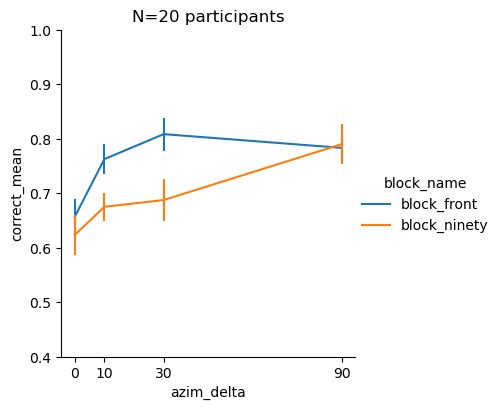

In [10]:
hue_order = ['block_front', 'block_ninety']
N = results_summary.participant.nunique()
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=4,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))
plt.title(f"N={N} participants")

Text(0.5, 1.0, 'N=20 participants')

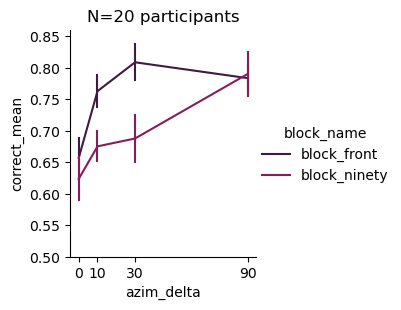

In [10]:
hue_order = ['block_front', 'block_fourty', 'block_ninety']
hue_order = ['block_front',  'block_ninety']
N = results_summary.participant.nunique()
cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate(['block_front', 'block_ninety'])}


g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                height=3,
                palette=palette,
                kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.5, .86, 0.05), ylim=(0.5, 0.86))
plt.title(f"N={N} participants")

In [136]:
## Run ttest 
from scipy.stats import ttest_rel

for azim_delta in results_summary.azim_delta.unique():
    front = results_summary.loc[(results_summary['azim_delta'] == azim_delta) & (results_summary['block_name'] == 'block_front'), 'correct_mean']
    ninety = results_summary.loc[(results_summary['azim_delta'] == azim_delta) & (results_summary['block_name'] == 'block_ninety'), 'correct_mean']
    t, p = ttest_rel(front, ninety)
    print(f"t={t}, p={p}, azim_delta={azim_delta}")

t=0.6670568725336543, p=0.5127562369364371, azim_delta=0
t=3.1782494552019074, p=0.004949603087930576, azim_delta=10
t=4.057348553907484, p=0.0006721242642195095, azim_delta=30
t=-0.2089331781852327, p=0.8367240839950241, azim_delta=90


### Run stats (2-way ANOVA)

In [159]:
to_anova = results_summary[results_summary.block_name != 'block_fourty'].copy()
to_anova.rename(columns={'block_name': 'target_azim', "azim_delta":'distractor_offset'}, inplace=True)

In [166]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.formula.api import ols
from scipy.stats import f
from statsmodels.stats.anova import AnovaRM


In [161]:
to_anova

,participant,target_azim,distractor_offset,correct_mean,correct_count,confusions_mean
4,participant_001,block_front,0,0.65,20,0.05
5,participant_001,block_front,10,0.65,20,0.00
6,participant_001,block_front,30,0.80,20,0.00
7,participant_001,block_front,90,0.95,20,0.00
8,participant_001,block_ninety,0,0.85,20,0.00
...,...,...,...,...,...,...
183,participant_013_v01,block_front,90,0.80,20,0.00
184,participant_013_v01,block_ninety,0,0.80,20,0.00
185,participant_013_v01,block_ninety,10,0.80,20,0.00
186,participant_013_v01,block_ninety,30,0.65,20,0.05


In [170]:
my_model_fit = AnovaRM(to_anova, 'correct_mean', 'participant', within=['target_azim', 'distractor_offset']).fit()
print(my_model_fit.anova_table)

                                 F Value  Num DF  Den DF        Pr > F
target_azim                     6.484656     1.0    19.0  1.970482e-02
distractor_offset              19.775549     3.0    57.0  6.558392e-09
target_azim:distractor_offset   3.179499     3.0    57.0  3.071463e-02


## Plot human and model together

In [46]:
## import experiment word map
human_exp_word_key = pickle.load( open(path_to_expmt_stim / "human_azim_spotlight_word_key.pkl", "rb" )) 
exp_word_2_class = {v:k for k,v in human_exp_word_key.items()}

In [80]:
# Path to results 

cols_to_merge = ['stim_name',
                 'word',
                 'sex_cond',
                 'target_transcripts',
                 'distractor_transcripts',
                 'distractor_word',

]

# output_paths = list(Path("binaural_eval/word_task_voice_loc_cue_only_v04").glob("*.pkl")) old path for more locations
import pickle
# match human pilot conditions
# model_name = 'word_task_half_co_loc_v06'
output_paths = list(Path(f"binaural_eval/simulate_2024_human_azimuth_spotlight_experiment_v02/").glob("*/*.pkl"))

word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

model_name_dict = {
                   "word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout": 'Feature-gain Model'
                  }


gend_map = {True:'same', False:'diff'}

for path in output_paths:
    if not any(name in str(path) for name in ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout']):# 'word_task_half_co_loc_v08']):
        continue

    # res_dict = pickle.load(open(path, 'rb'))
    try:
        df = pd.DataFrame(pd.read_pickle(path))
    
        df['response'] = df['preds'].replace(ix_to_word)
        df['true_word'] = df['true_word_int'].replace(ix_to_word)
        # df['confusions'] = (df.response == df.distractor_word).astype('int')
        # df['accuracy'] = (df.response == df.word).astype('int')


        # # add adjusted accuracy and confusions 
        # pred_words = df.response.values
        # target_words = df.word.values
        # target_transcripts = df.target_transcripts.values
        # distractor_words = df.distractor_word.values
        # distractor_transcripts = df.distractor_transcripts.values


        # adjusted_acc = np.array([int(pred_word in target_transcript or pred_word == target_word)
        #                             if not isinstance(target_transcript, float) else np.nan
        #                             for pred_word, target_word, target_transcript in zip(pred_words, target_words, target_transcripts)
        #                             ])

        # adjusted_confs = np.array([int(pred_word in distractor_transcript or pred_word == dist_word)
        #                             if not (isinstance(distractor_transcript, float)) else np.nan
        #                             for pred_word, dist_word, distractor_transcript in zip(pred_words, distractor_words,  distractor_transcripts)
        #                             ])

        # df['accuracy'] = adjusted_acc
        # df['confusions'] = adjusted_confs
        df.rename(columns={"results": "accuracy"}, inplace=True)

        df['target_azim'] = int(re.search('target_loc_(-?\d+)', path.stem).group(0).strip('target_loc_'))
        df['distractor_azim'] = int(re.search('distract_loc_(-?\d+)', path.stem).group(0).strip('distract_loc_'))
        df['target_azim'] = df['target_azim'].apply(remap_azim)
        df['distractor_azim'] = df['distractor_azim'].apply(remap_azim)
        
        
        # df.rename(columns={"results": "accuracy"}, inplace=True)
        df['model'] = model_name_dict[path.parent.stem]
        results_dfs.append(df)
    except Exception as error:
        print(error)
        print(path)
        continue


model_results = pd.concat(results_dfs)


In [84]:
model_results.target_azim.abs().unique(), model_results.distractor_azim.abs().unique()

(array([ 0, 90]), array([ 0, 10, 20, 90, 30, 40, 60, 80, 70, 50]))

In [77]:
(model_results.target_azim 

array([  0,  10,  20, -90,  30, -40, -30, -20, -10,  40,  60,  90, -60])

In [125]:
## Get and format model data for merging with human data
model_to_merge = model_results.copy()
model_to_merge['target_azim'] = model_to_merge['target_azim'].abs()
model_to_merge['distractor_azim'] = model_to_merge['distractor_azim'].abs()
model_to_merge['azim_delta'] = np.abs(model_to_merge['distractor_azim'] - model_to_merge['target_azim'])
model_to_merge = model_to_merge[model_to_merge['azim_delta'].isin([0, 10, 30, 90])]
model_to_merge['group'] = model_to_merge['model']
model_to_merge.rename(columns={'target_azim':'Target azimuth'}, inplace=True)
# same for human data
human_to_merge = results_summary[results_summary.block_name != 'block_fourty'].copy().reset_index(drop=True)
human_to_merge.rename(columns={'block_name': 'Target azimuth', 'correct_mean':'accuracy', 'confusions_mean':'confusions'}, inplace=True)
# rename values in column target azimuth 
human_to_merge['Target azimuth'] = human_to_merge['Target azimuth'].replace({'block_front': 0, 'block_ninety': 90})
N = human_to_merge.participant.nunique()
human_to_merge["group"] = f"Humans (N={N})"

# merge 
merged_df = pd.concat([model_to_merge, human_to_merge], ignore_index=True)
merged_df.dropna(axis=1, inplace=True)
merged_df['azim_delta'] = merged_df['azim_delta'].astype(int)
merged_df['Target azimuth'] = merged_df['Target azimuth'].astype(int)

/tmp/ipykernel_1831027/622345081.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  human_to_merge['Target azimuth'] = human_to_merge['Target azimuth'].replace({'block_front': 0, 'block_ninety': 90})


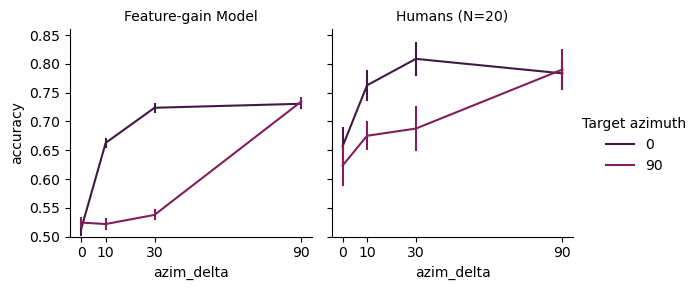

In [134]:
hue_order = [0,  90]

cmap = sns.color_palette('rocket', n_colors=5)
palette = {target_azim: cmap[i] for i, target_azim in enumerate([0, 90])}


g = sns.relplot(data=merged_df, x='azim_delta', y='accuracy',
                 hue='Target azimuth', hue_order=hue_order,
                 col='group',
                 errorbar=('se', 1),err_style='bars',
                height=3,
                palette=palette,
                kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.5, .86, 0.05), ylim=(0.5, 0.86))
g.set_titles("{col_name}")
# plt.title(f"N={N} participants")

## Look at each participants data

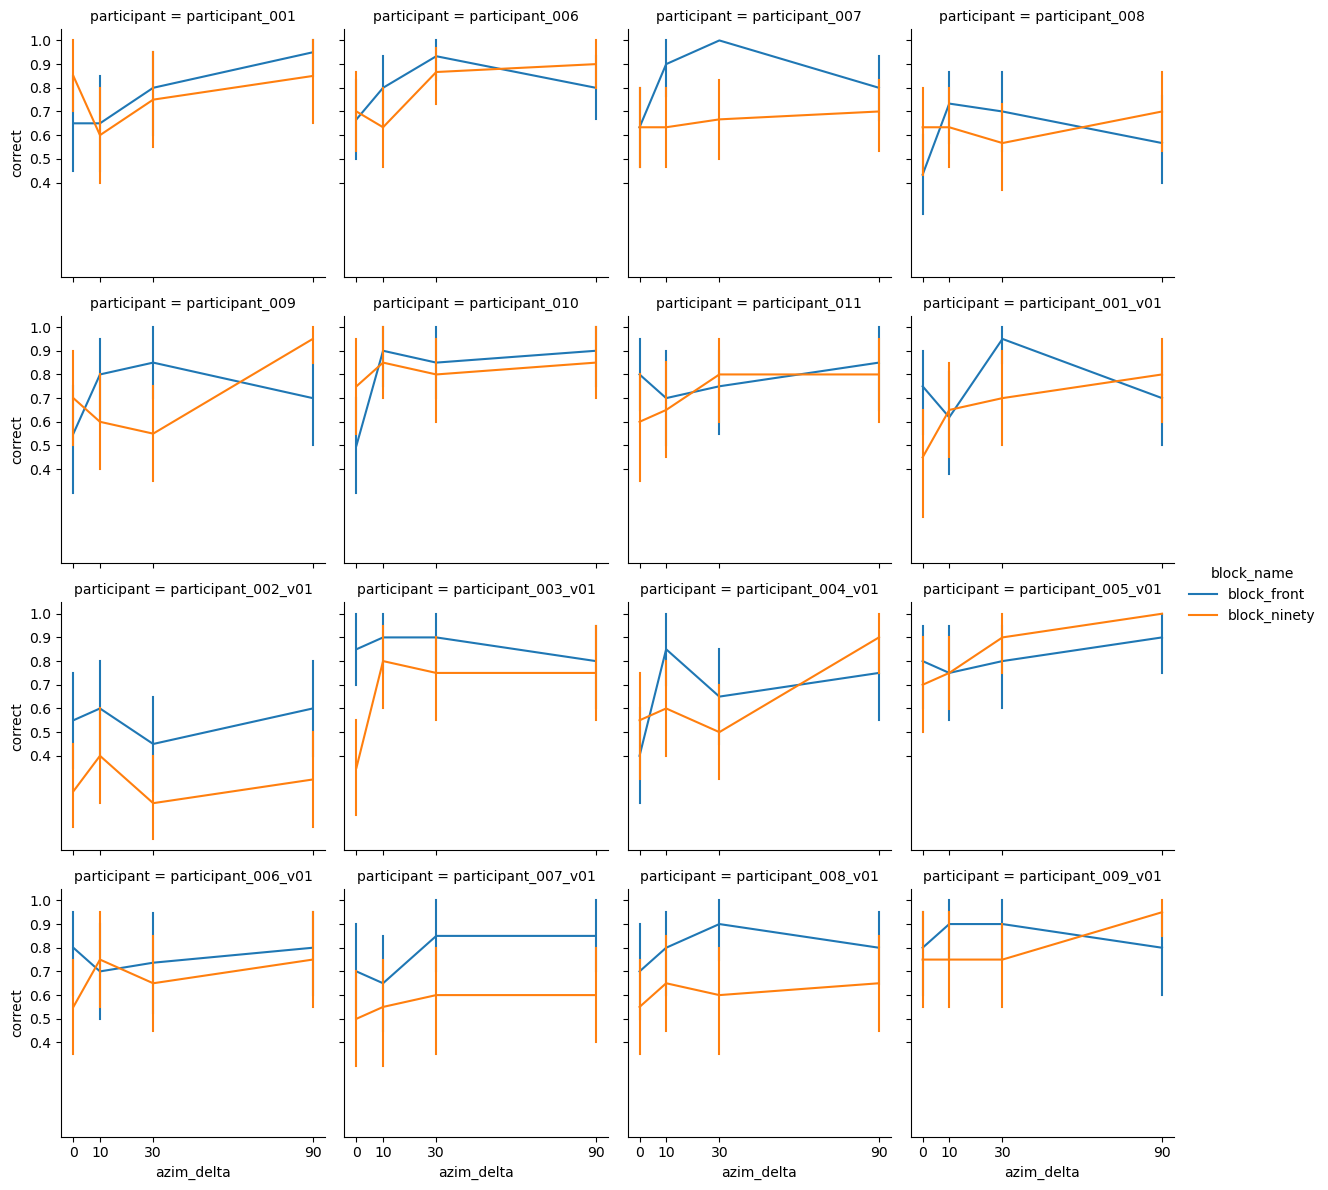

In [12]:
hue_order = ['block_front',  'block_ninety']
g = sns.relplot(data=results_df, x='azim_delta', y='correct',
                 hue='block_name',hue_order=hue_order,
                err_style='bars',
                 col='participant', col_wrap=4,
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

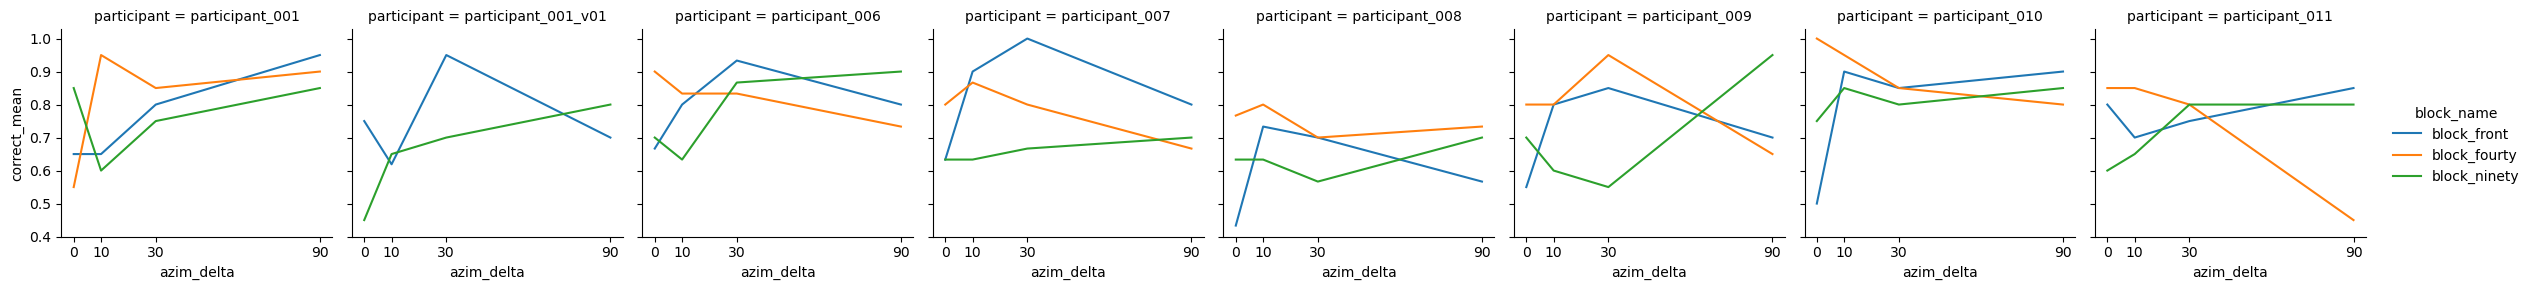

In [10]:
g = sns.relplot(data=results_summary, x='azim_delta', y='correct_mean',
                 hue='block_name', hue_order=hue_order,
                err_style='bars',
                 col='participant',
                height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique(), yticks=np.arange(0.4, 1.1, 0.1))

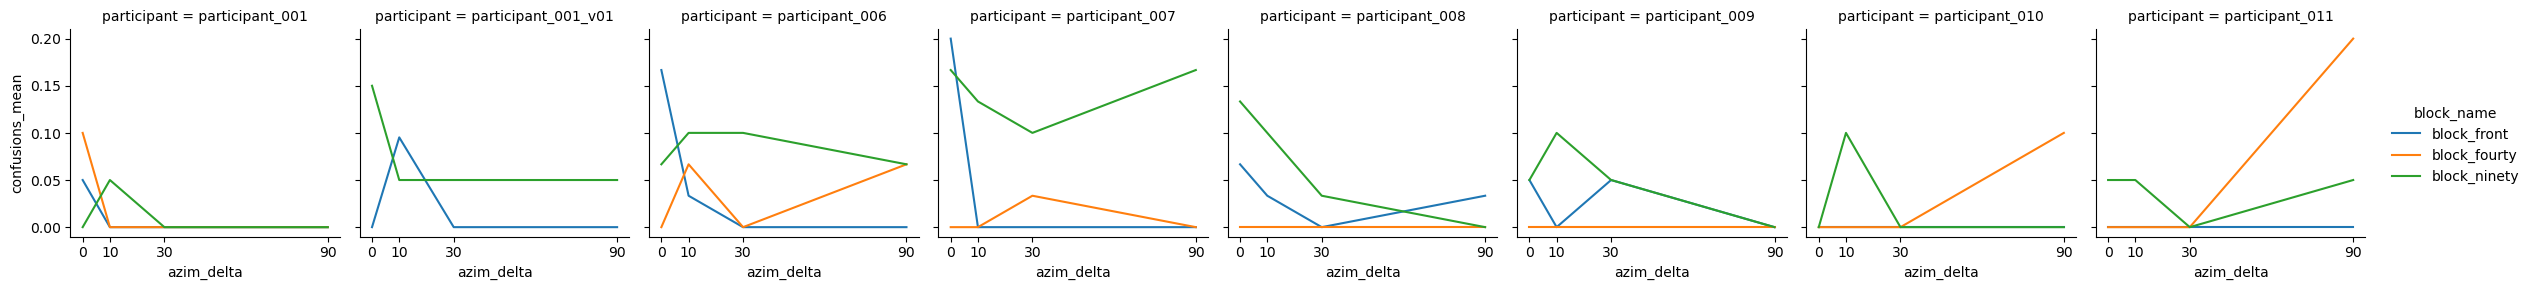

In [11]:
g = sns.relplot(data=results_summary, x='azim_delta', y='confusions_mean', 
                hue='block_name', hue_order=hue_order,
                 errorbar=('se', 1),err_style='bars',
                 col='participant',
                 height=3,
                  kind='line', aspect=1)
# set xticks to be the same as the azimuth deltas
g.set(xticks=results_summary['azim_delta'].unique())

# Run power analysis

In [15]:
results_summary

,participant,block_name,azim_delta,correct_mean,correct_count,confusions_mean
0,participant_001,block_fourty,0,0.55,20,0.10
1,participant_001,block_fourty,10,0.95,20,0.00
2,participant_001,block_fourty,30,0.85,20,0.00
3,participant_001,block_fourty,90,0.90,20,0.00
4,participant_001,block_front,0,0.65,20,0.05
...,...,...,...,...,...,...
87,participant_011,block_front,90,0.85,20,0.00
88,participant_011,block_ninety,0,0.60,20,0.05
89,participant_011,block_ninety,10,0.65,20,0.05
90,participant_011,block_ninety,30,0.80,20,0.00


In [25]:
## Get means of two groups at 10 azimuth 

target_0_delta_10 = results_summary[(results_summary.block_name == 'block_front') & (results_summary.azim_delta == 10)]
target_90_delta_10 = results_summary[(results_summary.block_name == 'block_ninety') & (results_summary.azim_delta == 10)]

# get difference of means 
diff = target_0_delta_10.correct_mean.mean() - target_90_delta_10.correct_mean.mean()
# get pooled standard deviation
n1 = target_0_delta_10.correct_count.sum()
n2 = target_90_delta_10.correct_count.sum()
s1 = target_0_delta_10.correct_mean.std()
s2 = target_90_delta_10.correct_mean.std()

pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))

effect_size = diff/ pooled_sd
effect_size

0.10654761904761911


1.1311094091801703

## Dev trial sampling for v01 in person experiment

In [12]:
SNRs = [0]

def draw_block_spotlight(distractor_side, target_azim):
    distractor_deltas = [0, 10, 30, 90] # use same as azimuth 
    # snrs = [0, -3, -6, -9]
    # return tuples of (target_loc, distractor_locs, azim_delta, elev_delta. snr)
    trials = []
    for delta in distractor_deltas:
      # calc elevation delta relative to most extreme position
      if distractor_side == 'right':
        if target_azim == 40:
          target_azim = -40 # flip dir and move distractors to right 
        dist_azim = target_azim + delta 
      elif distractor_side == 'left':
        if target_azim == 40:
          target_azim = 40 # flip dir and move distractors to right 
        dist_azim = target_azim - delta 
        
      trial = {'target_loc':(target_azim, 0),
               'distractor_loc':(dist_azim, 0),
               'azim_delta':delta,
               'elev_delta':0,
               'snr':0}
      
      trials.append(trial)
    return trials
  

In [13]:
import random

def sample_df(df, group, cond1, cond2, n):
	df_1 = df[df[f'{group}'] == cond1]
	df_2 = df[df[f'{group}'] == cond2]
	df_1_sample = df_1.sample(n=n)
	df_2_sample = df_2[~df_2.word.isin(df_1_sample.word)].sample(n=n)
    # keep original ixs to track metadata in analysis scripts 
	df_1_sample = df_1_sample.reset_index()
	df_1_sample.rename(columns={'index':'full_df_index'}, inplace=True)
	df_2_sample = df_2_sample.reset_index()
	df_2_sample.rename(columns={'index':'full_df_index'}, inplace=True)
	return pd.concat([df_1_sample, df_2_sample], axis=0, ignore_index=True)

def get_subset_df(df, n_words=480):
	n_to_samp = n_words // 4
	female_df = sample_df(df[df.gender == 'female'], 'sex_cond', 'same', 'different',n_to_samp)
	male_df = sample_df(df[(df.gender == 'male') & (~df.word.isin(female_df.word))], 'sex_cond', 'same', 'different', n_to_samp)
	return pd.concat([female_df, male_df], axis=0, ignore_index=True)



n_blocks_per_condition = 2 
num_trials_per_condition = 25
n_per_block = num_trials_per_condition // n_blocks_per_condition
print(n_per_block)

dist_side = 'left'
n_total_trials = 0 
experiment = {}
for block_num in range(n_blocks_per_condition):
    for target_loc in [0, 40, 90]:
        block = []
        block_str = f"target_{target_loc}_block_{block_num+1}"
        for trial_num in range(n_per_block):
            if target_loc == 90:
                block.extend(draw_block_spotlight(dist_side, 0))
            else:
                block.extend(draw_block_spotlight(dist_side, target_loc))
        n_total_trials += len(block)
        random.shuffle(block)
        experiment[block_str] = block

# experiment['target_40_block_1']
print(n_total_trials)

## Get speech excerpts 

to_sample = manifest[~manifest.client_id.str.contains('bowie|1906-cc|laurahale')]
participant_trial_stim_df = get_subset_df(to_sample, n_words=n_total_trials).sample(frac=1.0).reset_index(drop=True)

global_trial_ix = 0 
for block_name, trials in experiment.items():
    for i, trial in enumerate(trials):
        trial['cue_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_cue_src_fn'].split('/')[-1]
        trial['target_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_src_fn'].split('/')[-1]
        trial['distractor_fn'] = participant_trial_stim_df.loc[global_trial_ix, 'excerpt_distractor_1_src_fn'].split('/')[-1]
        trial['distractor_word'] = participant_trial_stim_df.loc[global_trial_ix, 'distractor_word'][0]
        trial['global_trial_ix'] = global_trial_ix
        trial['block_ix'] = i
        global_trial_ix += 1
        

12
288


In [31]:
from numpy.fft import irfft 

def normalize_to_white_noise(x):
    return x * np.sqrt(1 / np.mean(x**2))

def pink(N, state=None):
    """
    Pink noise.

    :param N: Amount of samples.
    :param state: State of PRNG.
    :type state: :class:`np.random.RandomState`

    Pink noise has equal power in bands that are proportionally wide.
    Power density decreases with 3 dB per octave.

    """
    state = np.random.RandomState() if state is None else state
    uneven = N % 2
    X = state.randn(N // 2 + 1 + uneven) + 1j * state.randn(N // 2 + 1 + uneven)
    S = np.sqrt(np.arange(len(X)) + 1.)  # +1 to avoid divide by zero
    y = (irfft(X / S)).real
    if uneven:
        y = y[:-1]

    return normalize_to_white_noise(y)


## Write in torch 

import torch
def pink_noise_torch(duration, n_examples=1):
    uneven = duration % 2
    X = torch.randn(duration // 2 + 1 + uneven) + 1j * torch.randn(duration // 2 + 1 + uneven)
    S = torch.sqrt(torch.arange(len(X)) + 1.)  # +1 to avoid divide by zero
    Y = (torch.fft.irfft(X / S)).real
    if uneven:
        Y = Y[:-1]
    return Y

In [34]:
N = int(44_100 * 2.5)
pink_noise = pink(N)

toch_pink_noise = pink_noise_torch(N)
print(len(toch_pink_noise))

110250


In [48]:
from IPython.display import Audio, display

Audio(pink_noise, rate=44_100, normalize=True)

In [27]:
Audio(toch_pink_noise, rate=44_100, normalize=True)

In [49]:
### Modify this to generate different pink noise examples as rows 

def pink_noise_torch(duration, n_examples=1):
    uneven = duration % 2
    X = torch.randn((n_examples, duration // 2 + 1 + uneven)) + 1j * torch.randn((n_examples, duration // 2 + 1 + uneven))
    S = torch.sqrt(torch.arange(X.shape[1]) + 1.)  # +1 to avoid divide by zero
    Y = (torch.fft.irfft(X / S)).real
    if uneven:
        Y = Y[:, : -1]
    return Y


pink_noise_egs = pink_noise_torch(88200, n_examples=3)

for eg  in pink_noise_egs:
    display(Audio(eg, rate=44_100, normalize=True))